In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate
from astropy import cosmology

In [3]:
data = np.load("dr7_quasar.npy")
#first points
data = data[:10000]
z = data["redshift"]

Text(0.5, 0, 'z')

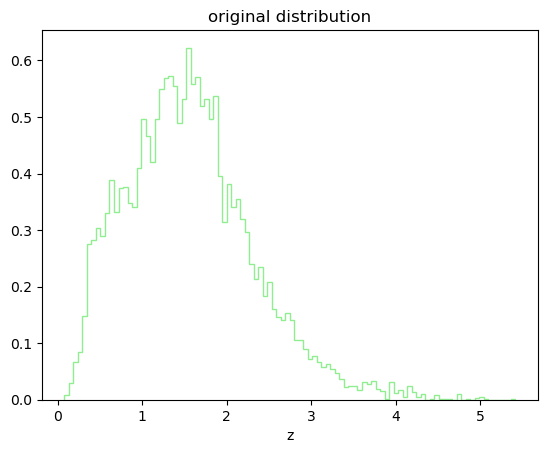

In [4]:
plt.hist(z, bins=100, density=True, histtype="step", color="lightgreen")
plt.title("original distribution")
plt.xlabel("z")

## inverse transform

Text(0.5, 0, 'z')

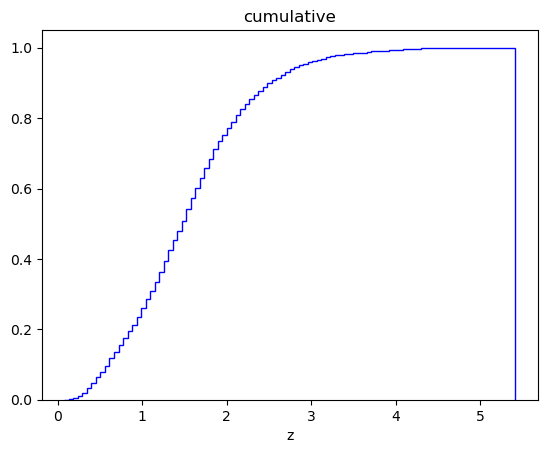

In [5]:
bars, bins, _ = plt.hist(z, bins=100, density=True, cumulative=True, histtype="step", color="b")
plt.title("cumulative")
plt.xlabel("z")

Text(0, 0.5, 'z')

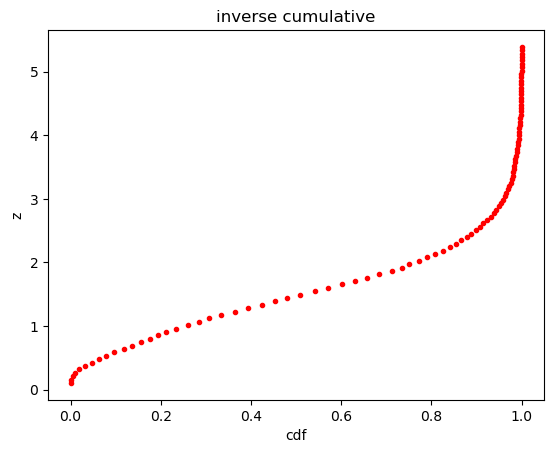

In [6]:
bin_points = [(bins[i]+bins[i+1])/2 for i in range(len(bins)-1)] #middle point of each bin
plt.plot(bars, bin_points, ".r") #inverse
plt.title("inverse cumulative")
plt.xlabel("cdf")
plt.ylabel("z")

Text(0.5, 1.0, 'interpolation')

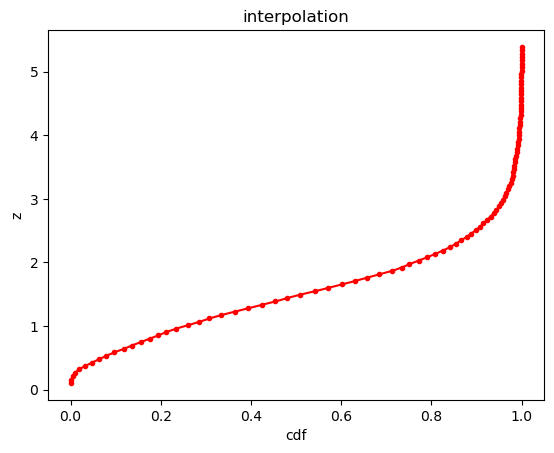

In [18]:
#now to make it continuous...
x = np.linspace(bars[0], bars[-1], 1000)
f = scipy.interpolate.interp1d(bars, bin_points)

plt.plot(bars, bin_points, ".r")
plt.plot(x, f(x), "-r")
plt.xlabel("cdf")
plt.ylabel("z")
plt.title("interpolation")

Text(0.5, 0, 'z')

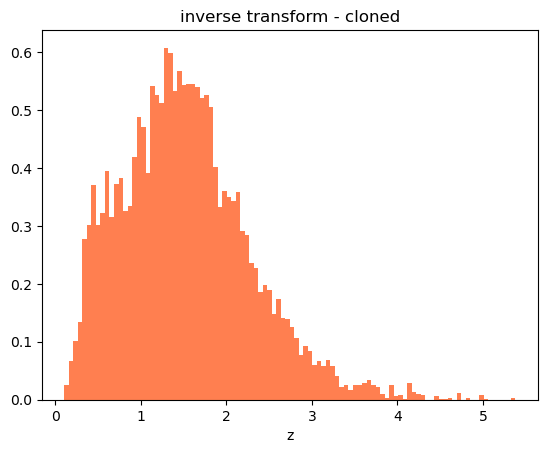

In [8]:
cdfrand = np.random.uniform(bars[0], bars[-1], 10000)
zrand = f(cdfrand) #the inverse of a random sample of the cumulative

plt.hist(zrand, bins=100, density=True, color="coral")
plt.title("inverse transform - cloned")
plt.xlabel("z")

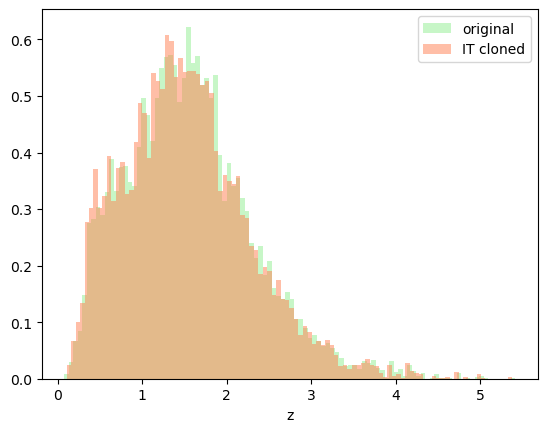

In [9]:
plt.hist(z, bins=100, density=True, label="original", alpha=0.5, color="lightgreen")
plt.hist(zrand, bins=100, density=True, label="IT cloned", alpha=0.5, color="coral")
plt.xlabel("z")
plt.legend()

## rejection sampling

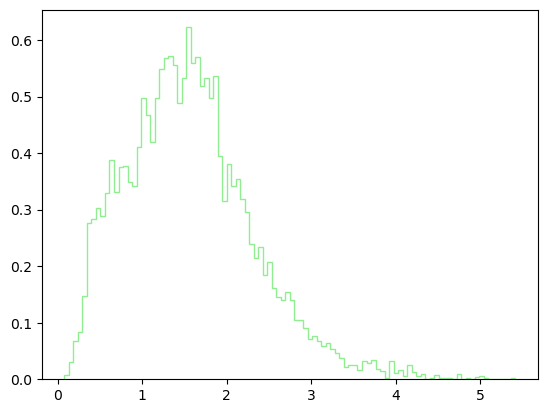

In [20]:
counts, bins, _ = plt.hist(z, bins=100, density=True, histtype="step", color="lightgreen")
#random points from uniform distribution to select
x = np.random.uniform(min(bins), max(bins), 10000)
y = np.random.uniform(0, max(counts), 10000)

In [22]:
bins_left = np.delete(bins, -1) #left edges
#bins_left<xi selects the indices of the bins that are smaller than xi: we want the last one, [-1], that gives the left edge of the bin where xi falls
#counts[bins_left<xi][-1] is the bar relative to the bin where xi falls, so we need to check whether yi is smaller than it or not
mask = np.array([yi<counts[bins_left<xi][-1] for xi, yi in zip(x, y)])

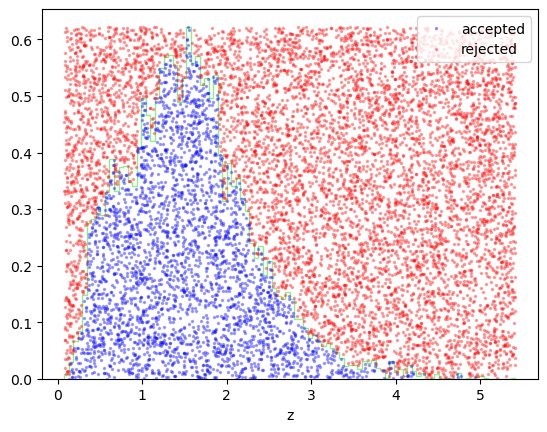

In [12]:
plt.hist(z, bins=100, density=True, histtype="step", color="lightgreen")
plt.plot(x[mask], y[mask], ".b", alpha=0.3, ms=3, label="accepted")
plt.plot(x[~mask], y[~mask], ".r", alpha=0.3, ms=3, label="rejected")
plt.xlabel("z")
plt.legend()

Text(0.5, 0, 'z')

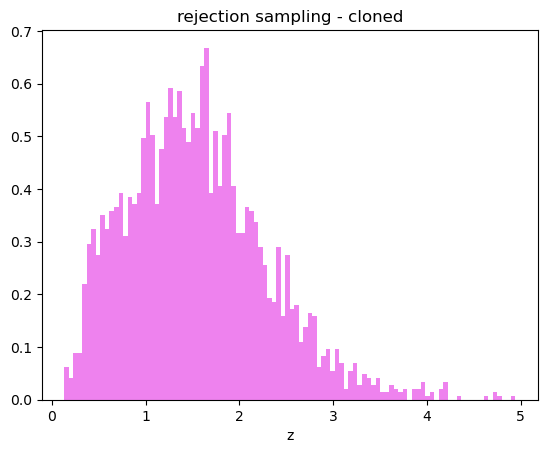

In [13]:
plt.hist(x[mask], bins=100, density=True, color="violet")
plt.title("rejection sampling - cloned")
plt.xlabel("z")

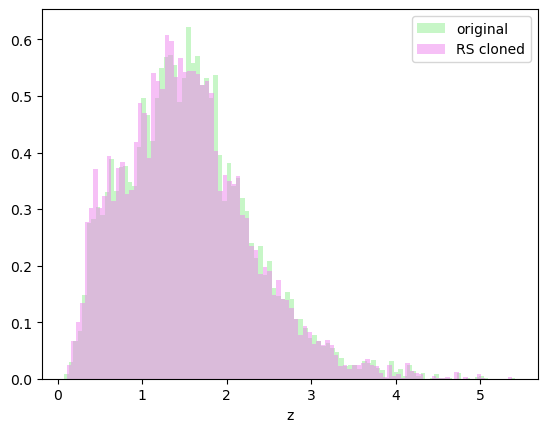

In [14]:
plt.hist(z, bins=100, density=True, label="original", alpha=0.5, color="lightgreen")
plt.hist(zrand, bins=100, density=True, label="RS cloned", alpha=0.5, color="violet")
plt.xlabel("z")
plt.legend()

## comparison

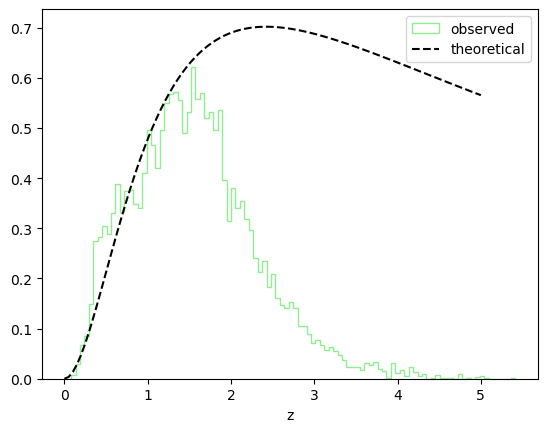

In [17]:
z_vals = np.linspace(0, 5, 100)
comvol = cosmology.Planck18.differential_comoving_volume(z_vals).value
plt.hist(z, bins=100, density=True, histtype="step", color="lightgreen", label="observed")
plt.plot(z_vals, comvol/6e10, "--k", label="theoretical")
plt.xlabel("z")
plt.legend()

... it doesn't fit because they're not distributed equally (Press & Schechter) and the furthest and faintest ones are too difficult to observe